In [32]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings(action='once')
import random
import math

In [33]:
newdf = pd.read_csv("batdongsan.com.vn.csv", dtype = {"month": "string" , "id" : "string"})
print("DONE")

DONE


In [34]:
newdf.columns

Index(['id', 'month', 'project', 'investor', 'square', 'bedrooms', 'bathrooms',
       'direction', 'balcony', 'district', 'ward', 'price'],
      dtype='str')

In [35]:
newdf.head()

,id,month,project,investor,square,bedrooms,bathrooms,direction,balcony,district,ward,price
0,28086120,12,Vinhomes Smart City Đại Mỗ,Tập đoàn Vingroup,60.0,3.0,1.0,Đông-Nam,Tây-Bắc,nam tu liem,dai mo,1560.0
1,28088954,12,Goldmark City,Công ty TNHH Thương mại - Quảng cáo - Xây dựng...,121.0,3.0,2.0,NaN,NaN,bac tu liem,phu dien,3300.0
2,28097966,12,Chung cư IEC Tứ Hiệp,NaN,70.0,2.0,2.0,Tây-Bắc,Đông-Nam,thanh tri,tu hiep,1106.0
3,27895887,12,Vinhomes D'Capitale,Tân Hoàng Minh Group,39.0,1.0,1.0,Đông-Nam,Đông-Nam,cau giay,trung hoa,1500.0
4,28056031,12,The Zen Residence,Công ty TNHH Gamuda Land Việt Nam,97.0,3.0,2.0,NaN,NaN,hoang mai,hoang liet,2900.0


/opt/miniconda3/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


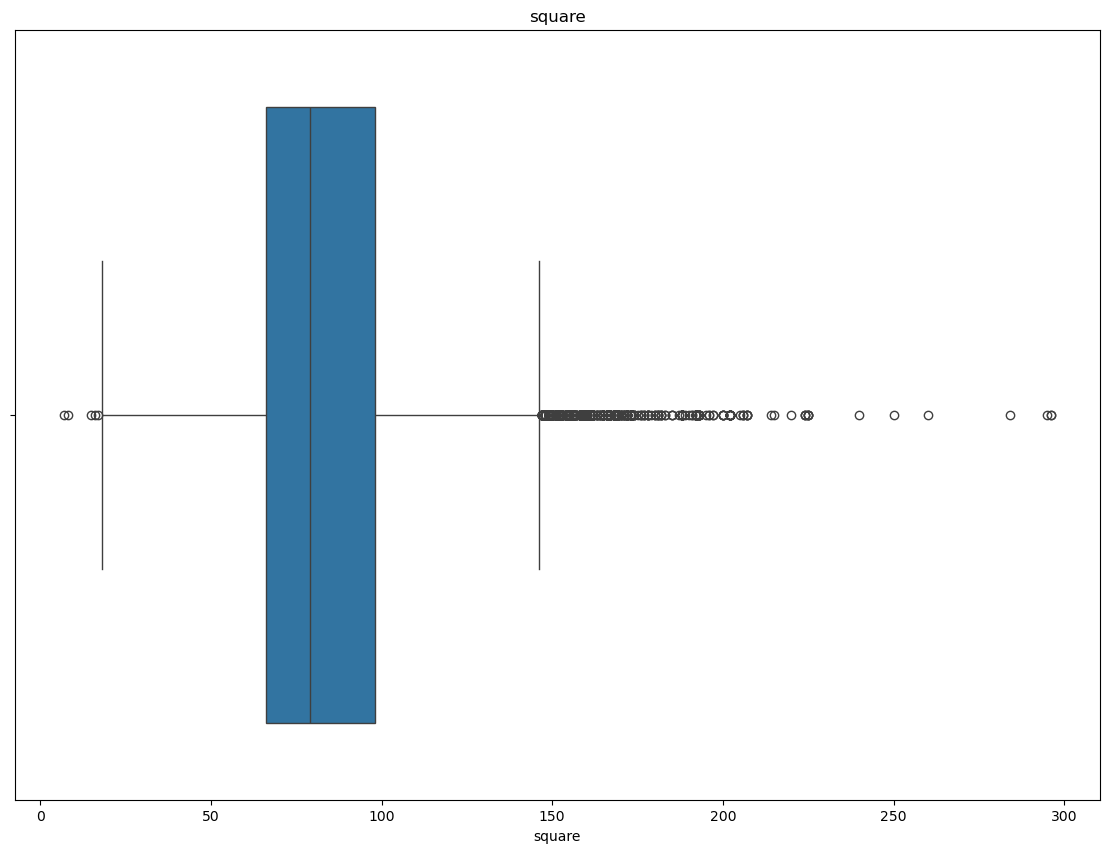

/opt/miniconda3/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


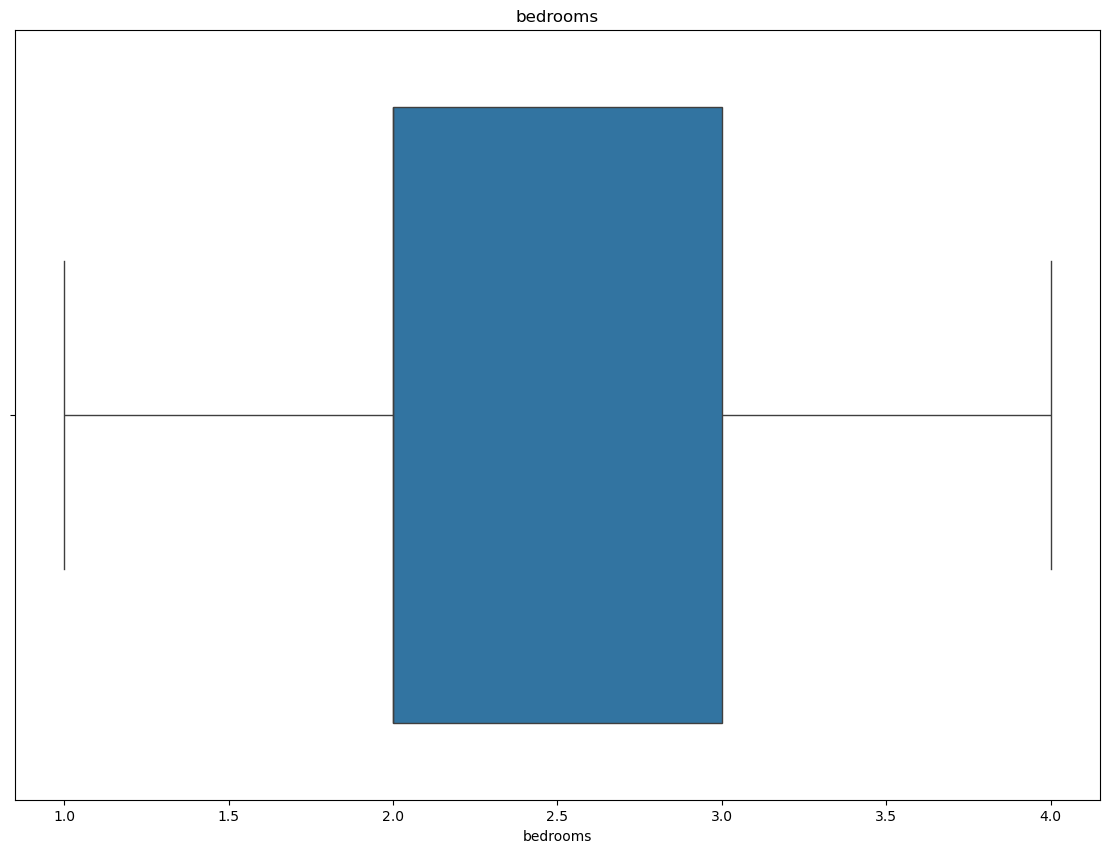

/opt/miniconda3/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


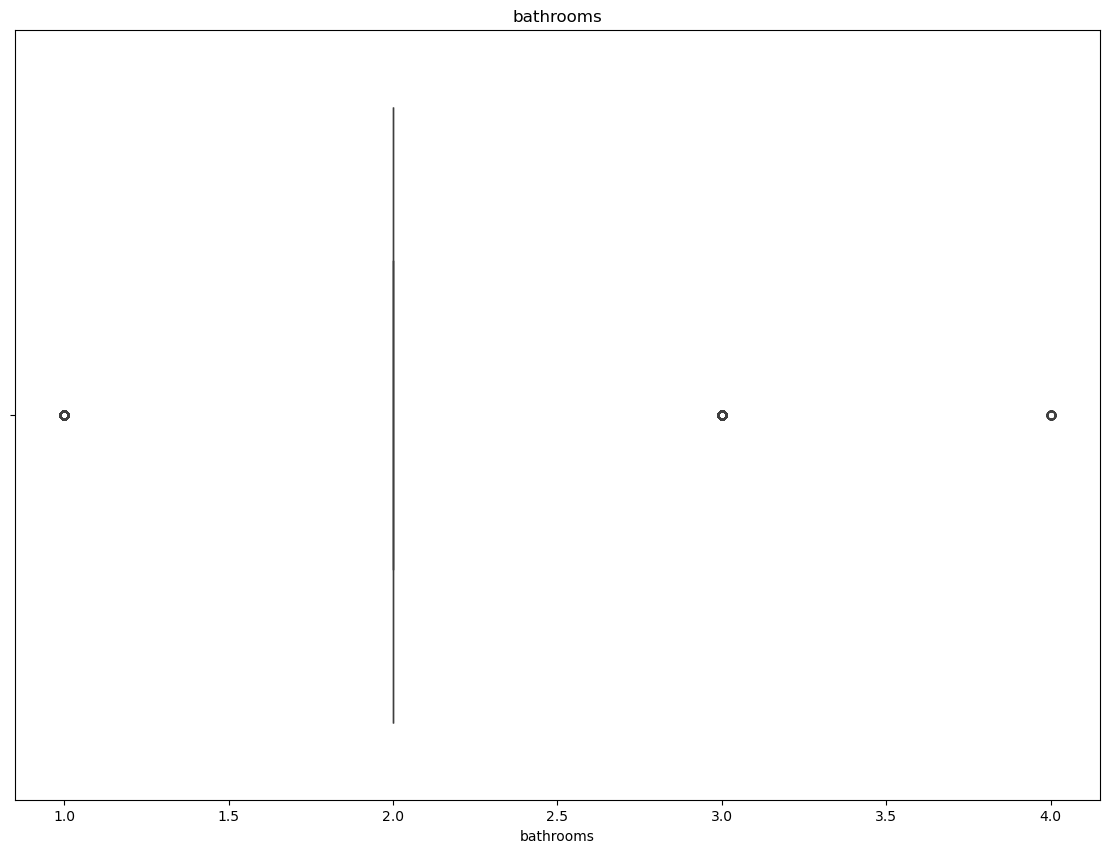

/opt/miniconda3/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


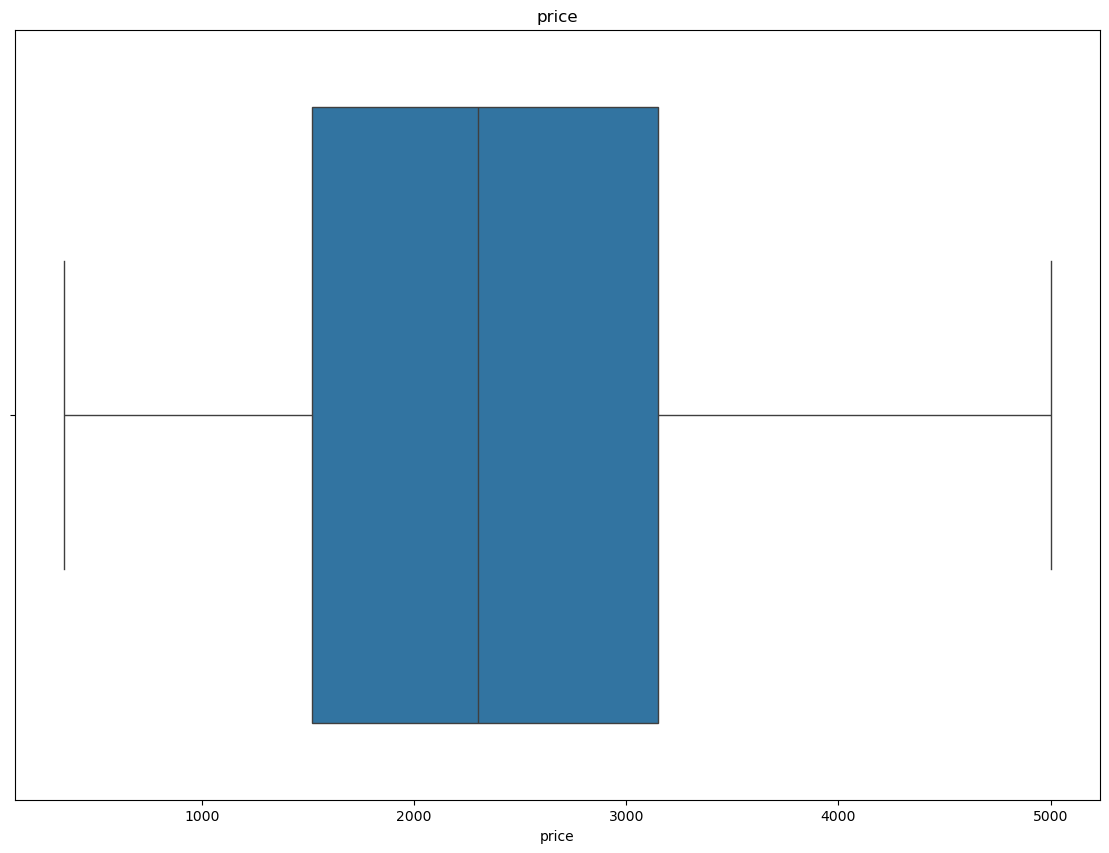

In [36]:
vars=['square', 'bedrooms', 'bathrooms', 'price']
for var in vars:
    plt.figure(figsize=(14,10))
    sns.boxplot(x=newdf[var])
    plt.title(var)
    plt.show()



/var/folders/2r/vw2t59sn3pq2xsn2gn9892fc0000gn/T/ipykernel_1817/1920162332.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df1['month'], rotation=60, horizontalalignment= 'right')


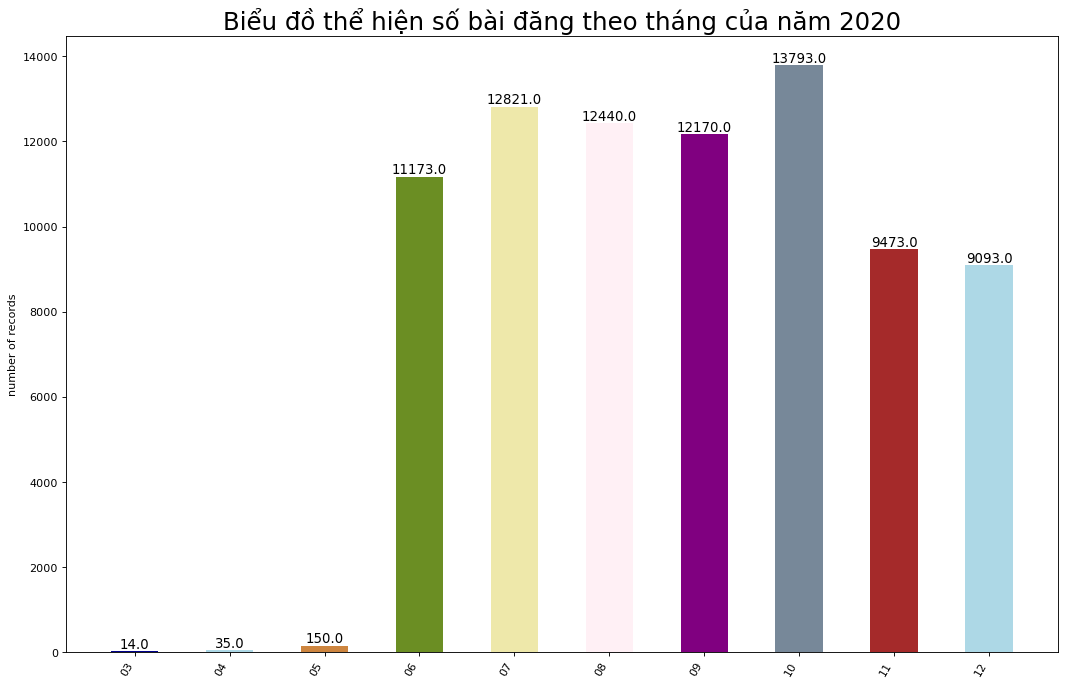

In [37]:
df1 = newdf.groupby('month').size().reset_index(name='number of records')
n = df1['month'].unique().__len__()+1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)

plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df1['month'], df1['number of records'], color=c, width=.5)
for i, val in enumerate(df1['number of records'].values):
    plt.text(i, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

plt.gca().set_xticklabels(df1['month'], rotation=60, horizontalalignment= 'right')
plt.title("Biểu đồ thể hiện số bài đăng theo tháng của năm 2020", fontsize=22)
plt.ylabel('number of records')
plt.show()

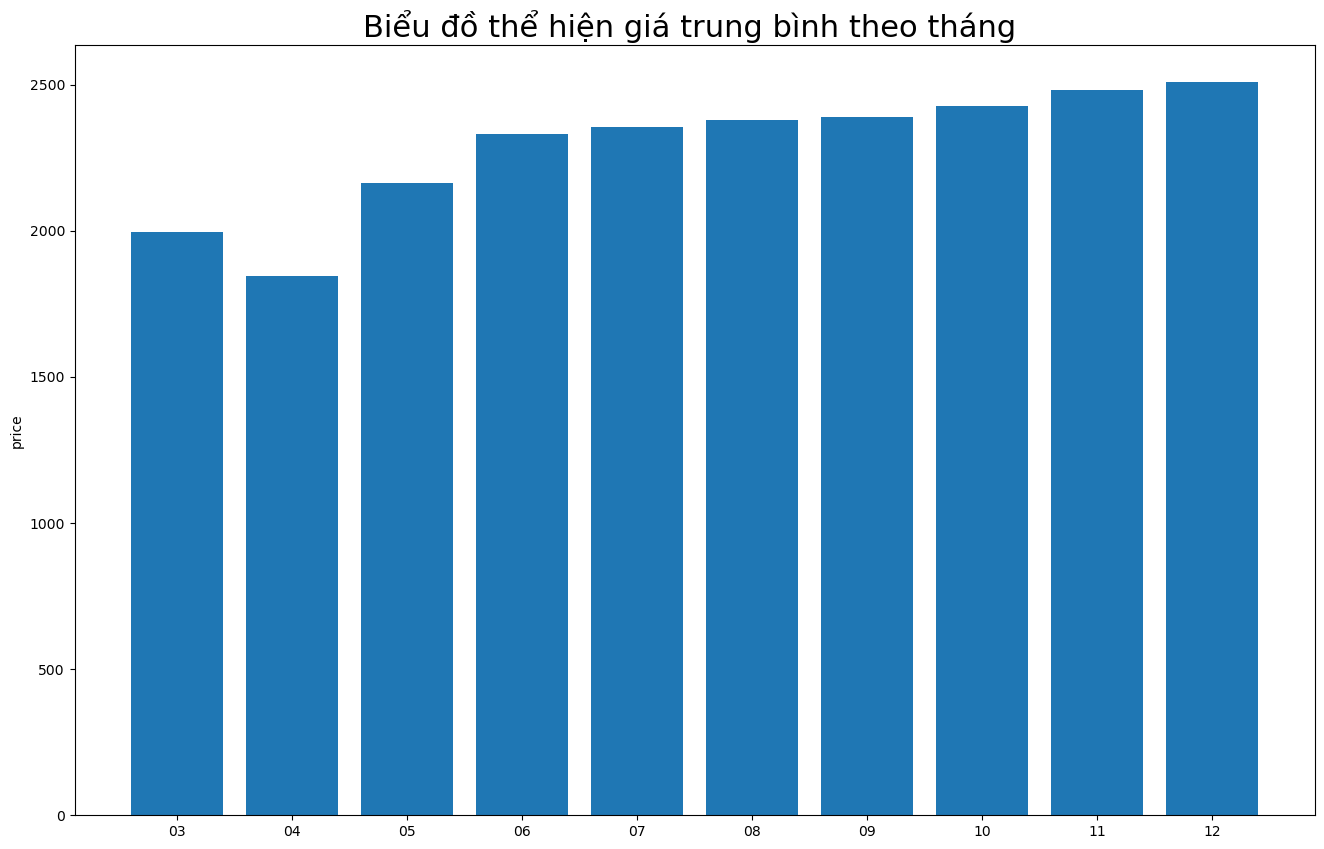

In [38]:
df2=newdf.groupby('month')['price'].mean().reset_index(name='mean_price')
plt.figure(figsize=(16,10))
plt.bar(df2['month'], df2['mean_price'])
plt.title("Biểu đồ thể hiện giá trung bình theo tháng ", fontsize=22)
plt.ylabel('price')
plt.show()

<Figure size 1600x1000 with 0 Axes>

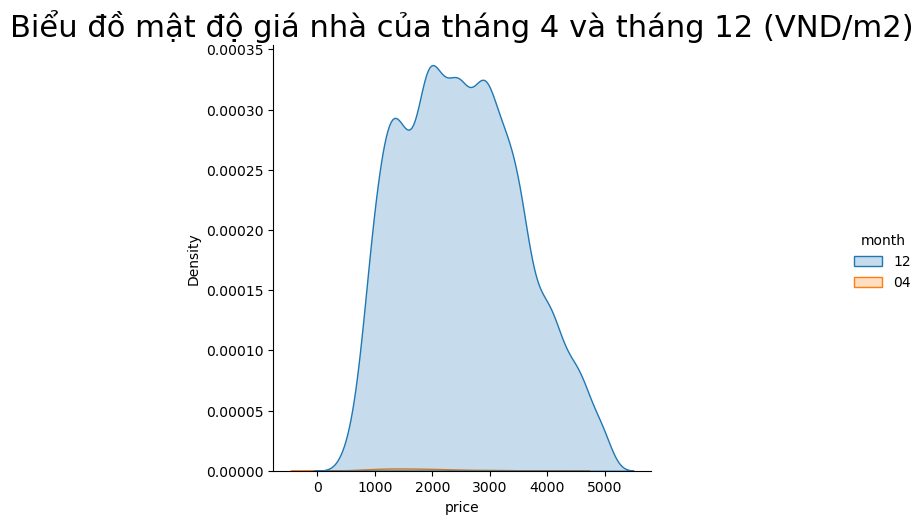

In [39]:
df_price=newdf[newdf['month'].isin(['04','12'])]
plt.figure(figsize=(16,10))
sns.displot(data=df_price, x='price', hue='month', kind='kde', fill=True)
plt.title("Biểu đồ mật độ giá nhà của tháng 4 và tháng 12 (VND/m2)", fontsize=22)
plt.show()

In [40]:
newdf['bedrooms'].value_counts()

bedrooms
2.0    45317
3.0    29543
1.0     4158
4.0     2144
Name: count, dtype: int64

In [41]:
df3=newdf.groupby('bedrooms')
df3['price'].mean()


bedrooms
1.0    1342.610974
2.0    2019.564821
3.0    3037.271291
4.0    3890.328032
Name: price, dtype: float64

In [42]:
df4=newdf.groupby('district')
df4['price'].mean()

district
ba dinh         3335.350456
bac tu liem     3041.182833
cau giay        3033.774841
chuong my        687.321176
dan phuong      1117.530702
dong anh        1415.668997
dong da         2693.787442
gia lam         1698.436365
ha dong         1635.687684
hai ba trung    3227.851373
hoai duc        1337.237347
hoan kiem       2761.875000
hoang mai       1589.681570
long bien       2126.505218
me linh         1111.900000
nam tu liem     2630.895551
quoc oai         592.620000
tay ho          3199.681908
thach that       832.200000
thanh oai        804.846300
thanh tri       1895.560240
thanh xuan      2889.001056
thuong tin       706.666667
Name: price, dtype: float64

In [43]:
df_hoankiem=newdf[newdf['district']=='hoan kiem']
df_hoankiem['price'].mean()

np.float64(2761.875)

In [44]:
df_investor=newdf.groupby('investor')['price'].mean().sort_values(ascending=False).head(10)
df_investor

investor
Công ty CP Hạ tầng và Bất động sản Việt Nam            4850.444444
Tập đoàn BRG                                           4648.222222
Công ty Liên doanh Hà Việt – Tungshing                 4547.500000
Công ty TNHH Indochina Land                            4508.349367
Công ty TNHH Nhà nước một thành viên Thăng Long GTC    4445.923077
Công ty CP Đầu tư và Phát triển Thương mại Kinh Đô     4399.750000
Công ty CP Đầu tư Xây dựng Dân dụng Hà Nội             4383.033333
TTTM XNK Hàng tiêu dùng và Thủ công Mỹ nghệ Hà Nội     4339.277778
Công ty CP Đầu tư Phát triển nhà Gia Bảo               4316.800000
Công ty CP Tư vấn Kiến trúc Đô thị Hà Nội - UAC        4301.333333
Name: price, dtype: float64

In [46]:
newdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 81163 entries, 0 to 81162
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         81163 non-null  string 
 1   month      81162 non-null  string 
 2   project    78097 non-null  str    
 3   investor   65453 non-null  str    
 4   square     81162 non-null  float64
 5   bedrooms   81162 non-null  float64
 6   bathrooms  81162 non-null  float64
 7   direction  51086 non-null  str    
 8   balcony    54426 non-null  str    
 9   district   81162 non-null  str    
 10  ward       79506 non-null  str    
 11  price      81162 non-null  float64
dtypes: float64(4), str(6), string(2)
memory usage: 7.4 MB


In [47]:
drop_df=newdf.drop(['id','month','project','investor','direction','balcony','district','ward'],axis=1)

<Axes: >

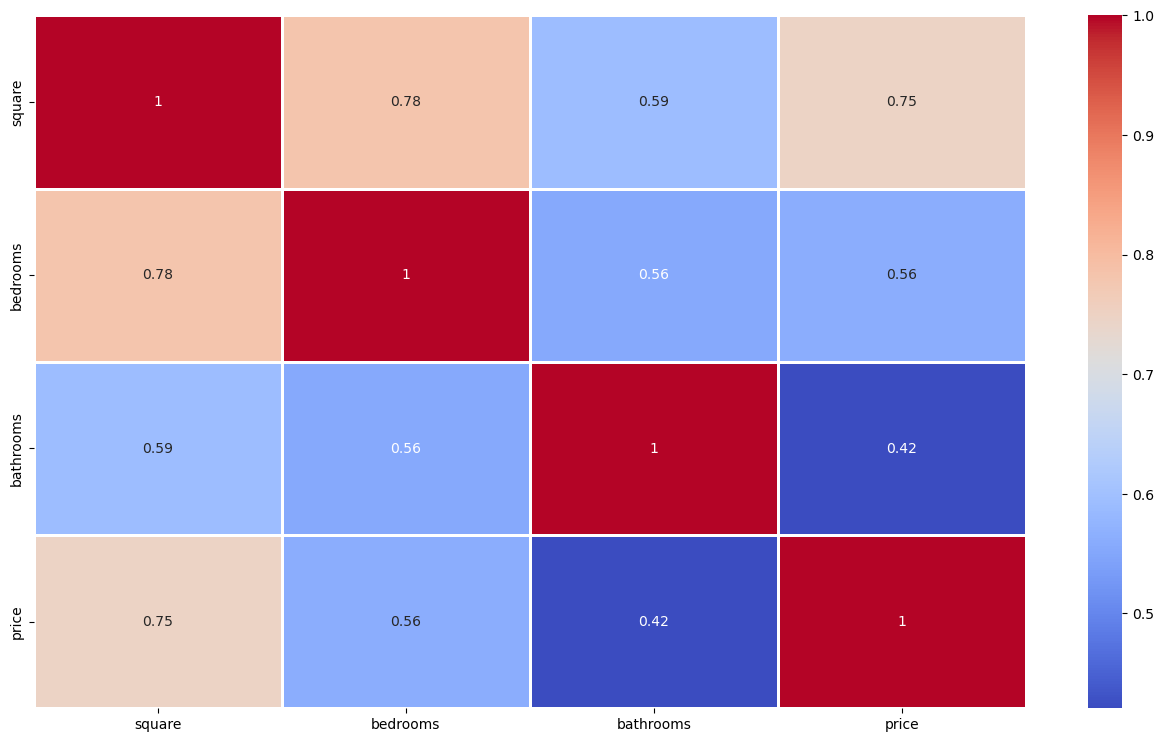

In [48]:
plt.figure(figsize=(16,9))
sns.heatmap(drop_df.corr(), annot=True, cmap='coolwarm', linewidths=2)

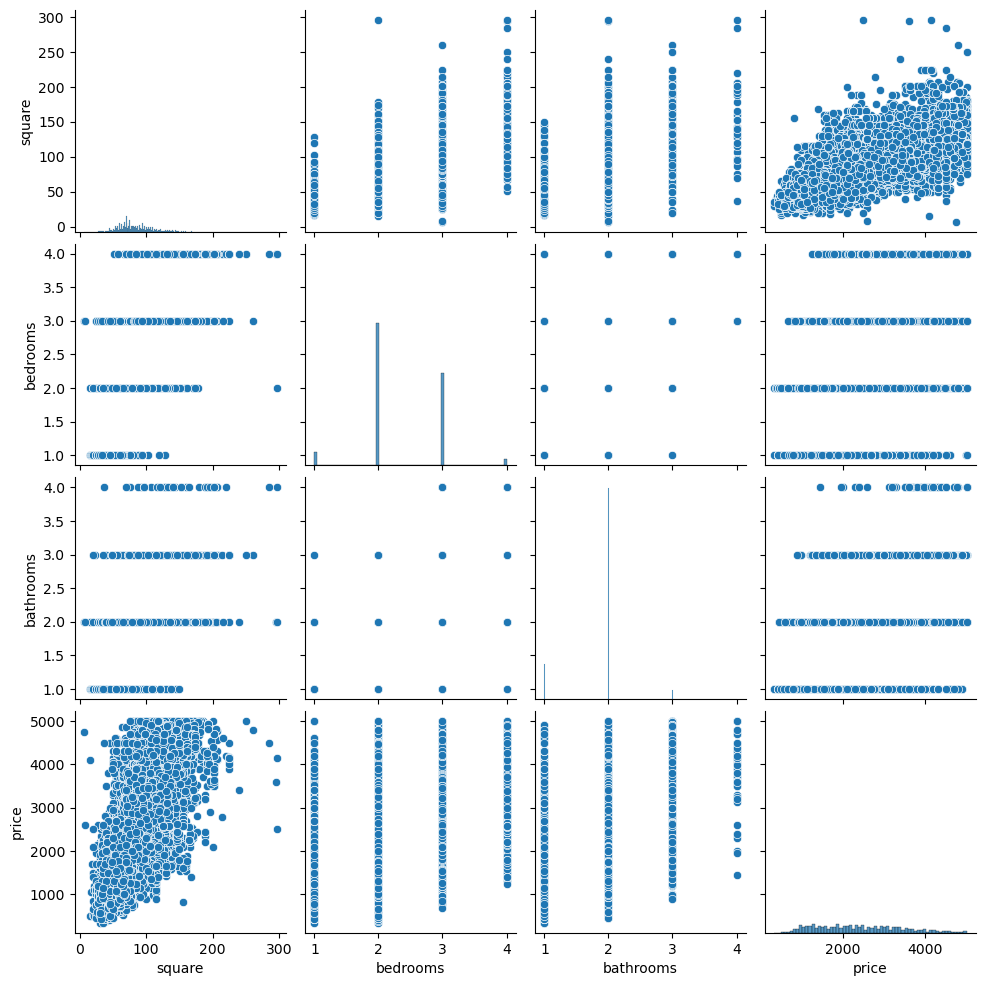

In [49]:
sns.pairplot(drop_df)

<Figure size 1600x1000 with 0 Axes>

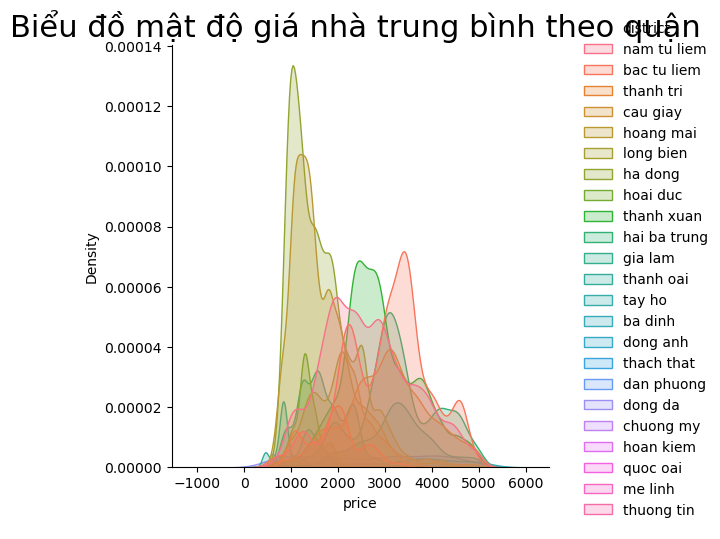

In [55]:
df_district=newdf[['district','price']]
plt.figure(figsize=(16,10))
sns.displot(data=df_district, x='price', hue='district', kind='kde', fill=True)
plt.title("Biểu đồ mật độ giá nhà trung bình theo quận ", fontsize=22)
plt.show()